<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Entangle005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

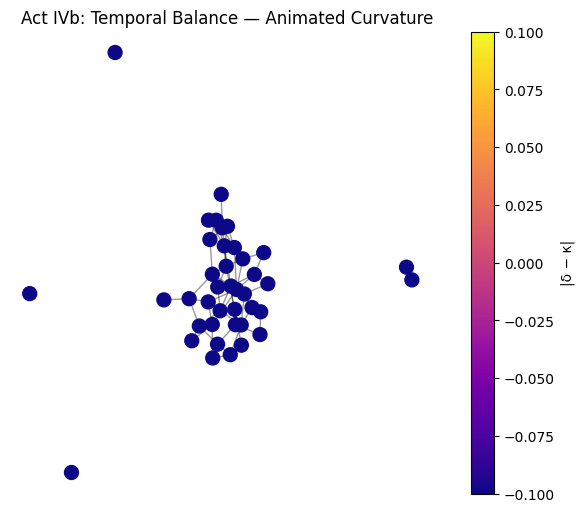

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation

# -------------------------------
# Step 1: Build Bipartite Network
# -------------------------------
def build_boundary_bulk_network(boundary_size=8, bulk_size=32):
    G = nx.Graph()
    boundary_nodes = [f"B{i}" for i in range(boundary_size)]
    bulk_nodes = [f"U{i}" for i in range(bulk_size)]

    G.add_nodes_from(boundary_nodes, region='boundary')
    G.add_nodes_from(bulk_nodes, region='bulk')

    for b in boundary_nodes:
        connections = np.random.choice(bulk_nodes, size=4, replace=False)
        for u in connections:
            G.add_edge(b, u)

    for i in range(bulk_size):
        for j in range(i + 1, bulk_size):
            if np.random.rand() < 0.05:
                G.add_edge(f"U{i}", f"U{j}")

    return G

# -------------------------------
# Step 2: Dynamic δ(t) and κ(t)
# -------------------------------
def update_weights(G, t, δ_max=1.0, κ_max=1.0):
    δ_t = δ_max * np.sin(2 * np.pi * t / 50)
    κ_t = κ_max * np.cos(2 * np.pi * t / 50)
    for node in G.nodes:
        region = G.nodes[node]['region']
        G.nodes[node]['delta'] = δ_t if region == 'boundary' else 0.0
        G.nodes[node]['kappa'] = κ_t if region == 'bulk' else 0.0

# -------------------------------
# Step 3: Compute Curvature
# -------------------------------
def compute_curvature(G):
    return {node: np.abs(G.nodes[node]['delta'] - G.nodes[node]['kappa']) for node in G.nodes}

# -------------------------------
# Step 4: Animate Network
# -------------------------------
def animate_holographic_flow(G, frames=100):
    pos = nx.spring_layout(G, seed=42)
    fig, ax = plt.subplots(figsize=(7, 6))

    initial_colors = [0.0 for _ in G.nodes]
    nodes = nx.draw_networkx_nodes(G, pos, node_size=100, node_color=initial_colors, cmap='plasma', ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax)

    sm = ScalarMappable(cmap='plasma')
    sm.set_array(initial_colors)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('|δ − κ|')
    ax.set_title("Act IVb: Temporal Balance — Animated Curvature")
    plt.axis('off')

    def update(frame):
        update_weights(G, frame)
        curvature = compute_curvature(G)
        node_colors = [curvature[n] for n in G.nodes]
        nodes.set_array(np.array(node_colors))
        sm.set_array(node_colors)
        return nodes,

    anim = FuncAnimation(fig, update, frames=frames, interval=100, blit=False)
    plt.show()

# -------------------------------
# Step 5: Run Animation
# -------------------------------
G = build_boundary_bulk_network()
animate_holographic_flow(G)
